# Checkpoint 3 — Noise Reduction: Data Preparation and Analysis


## 0. Setup

In [1]:
!pip install datasets==3.6.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 12.0 MB/s eta 0:00:00
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0


In [ ]:
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import soundfile as sf
import librosa
from datasets import load_dataset
from tqdm.auto import tqdm

In [ ]:
SEED = 31122002
random.seed(SEED)
np.random.seed(SEED)

In [23]:
PROCESSED_DIR = Path("data/processed")
MANIFEST_DIR = Path("data/manifests")
EDA_DIR = Path("eda/noise_reduction")

for d in [PROCESSED_DIR, MANIFEST_DIR, EDA_DIR]:
    d.mkdir(parents=True, exist_ok=True)

TARGET_SR = 16_000
TARGET_SUBTYPE = "PCM_16"
PEAK_TARGET = 0.9

SAVE_TO_DISK = True

## 1. SNR

**SNR (Signal-to-Noise Ratio):**  
Given a paired clean signal $x$ and noisy signal $y$, the noise is $n = y - x$, and:
$$\text{SNR} = 10 \log_{10} \frac{\|x\|^2}{\|n\|^2}$$

We use this to verify that the dataset SNR levels match what is reported in the literature,
and to stratify our EDA results by noise level.

Now we only compute SNR for EDA.

In [24]:
def estimate_snr(clean, noisy):
    if len(clean) != len(noisy):
        n = min(len(clean), len(noisy))
        clean, noisy = clean[:n], noisy[:n]
    signal_power = np.mean(clean ** 2)
    noise_power = np.mean((noisy - clean) ** 2)
    if noise_power < 1e-10:
        return float("inf")
    return float(10 * np.log10(signal_power / noise_power))

## 2. Preprocessing
Resample and convert to mono.

In [4]:
def preprocess(array, src_sr):
    y = array.astype(np.float32)
    if src_sr != TARGET_SR:
        y = librosa.resample(y, orig_sr=src_sr, target_sr=TARGET_SR)
    if y.ndim > 1:
        y = librosa.to_mono(y)
    return y

def save_audio(array, path):
    path.parent.mkdir(parents=True, exist_ok=True)
    sf.write(str(path), array, TARGET_SR, subtype=TARGET_SUBTYPE)

Preprocessing functions ready.


## 3. Load URGENT challenge 2024
 https://huggingface.co/datasets/urgent-challenge/urgent2024_official

In [5]:
urgent_raw = load_dataset(
    "urgent-challenge/urgent2024_official",
    "test_nonblind",
    split = "validation",
    trust_remote_code=True,
)
print(f"Features: {urgent_raw.features}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/test_nonblind/test_nonblind-00000-o(…):   0%|          | 0.00/734M [00:00<?, ?B/s]

Generating validation split:   0%|          | 0/1000 [00:00<?, ? examples/s]

URGENT 2024 non-blind test: 1,000 samples
Features: {'id': Value(dtype='string', id=None), 'sampling_rate': Value(dtype='int32', id=None), 'noisy_audio': Audio(sampling_rate=None, mono=True, decode=True, id=None), 'clean_audio': Audio(sampling_rate=None, mono=True, decode=True, id=None), 'transcript': Value(dtype='string', id=None), 'snr_dB': Value(dtype='float32', id=None)}


In [29]:
s = urgent_raw[0]
print(f"sampling_rate: {s['sampling_rate']}")
print(f"noisy SR: {s['noisy_audio']['sampling_rate']}")
print(f"clean SR: {s['clean_audio']['sampling_rate']}")

sampling_rate: 48000
noisy SR: 48000
clean SR: 48000


In [27]:
urgent_raw.take(1)

Dataset({
    features: ['id', 'sampling_rate', 'noisy_audio', 'clean_audio', 'transcript', 'snr_dB'],
    num_rows: 1
})


## 4. Build Manifest

The manifest for noise reduction has **two audio paths per row** — clean and noisy.  
We also compute the actual SNR from the signals (not just the target level)  
to verify the mixing was done correctly.

In [48]:
def build_manifest(dataset) -> pd.DataFrame:
    rows = []
    for i, sample in enumerate(tqdm(dataset, desc="URGENT 2024")):
        fid = sample["id"]
        orig_sr = sample["sampling_rate"]
        c_aud = sample["clean_audio"]
        n_aud = sample["noisy_audio"]

        c_arr = preprocess(np.array(c_aud["array"], dtype=np.float32), c_aud["sampling_rate"])
        n_arr = preprocess(np.array(n_aud["array"], dtype=np.float32), n_aud["sampling_rate"])
        c_path = PROCESSED_DIR/"urgent2024_test"/"clean"/f"{fid}.wav"
        n_path = PROCESSED_DIR/"urgent2024_test"/"noisy"/f"{fid}.wav"

        save_audio(c_arr, c_path)
        save_audio(n_arr, n_path)

        snr_actual = estimate_snr(c_arr, n_arr)

        rows.append({
            "id": fid,
            "clean_path": str(c_path),
            "noisy_path": str(n_path),
            "duration_sec": round(len(c_arr) / TARGET_SR, 4),
            "snr_target_db": float(sample["snr_dB"]),
            "snr_actual_db": round(snr_actual, 2),
            "orig_sr": orig_sr,
            "transcript": sample.get("transcript", ""),
            "sample_rate": TARGET_SR,
        })
    return pd.DataFrame(rows)

In [49]:
m_urgent = build_manifest(urgent_raw)
m_urgent.to_csv(MANIFEST_DIR / "nr_urgent2024_test.csv", index=False)
print(m_urgent[["duration_sec", "snr_target_db", "snr_actual_db", "orig_sr"]].describe().round(2))

URGENT 2024:   0%|          | 0/1000 [00:00<?, ?it/s]

       duration_sec  snr_target_db  snr_actual_db   orig_sr
count       1000.00        1000.00        1000.00   1000.00
mean           6.93           7.43           4.04  27463.20
std            2.03           7.27           6.25   9438.47
min            2.51          -4.98         -11.32  16000.00
25%            6.12           1.16          -0.64  22050.00
50%            6.95           7.30           3.28  24000.00
75%            7.92          14.05           7.76  32000.00
max           14.73          19.98          19.50  48000.00


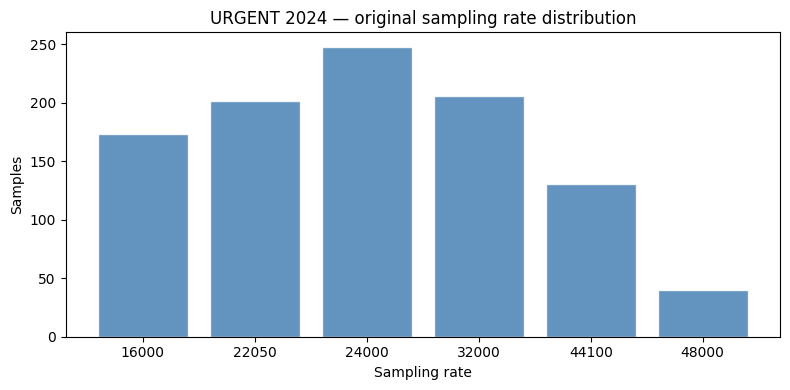

In [35]:
sr_counts = m_urgent["orig_sr"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(sr_counts.index.astype(str), sr_counts.values, color="steelblue", edgecolor="white", alpha=0.85)
ax.set_title("URGENT 2024 — original sampling rate distribution")
ax.set_xlabel("Sampling rate")
ax.set_ylabel("Samples")
plt.tight_layout()
plt.savefig(EDA_DIR / "02b_original_sr.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. EDA — Duration

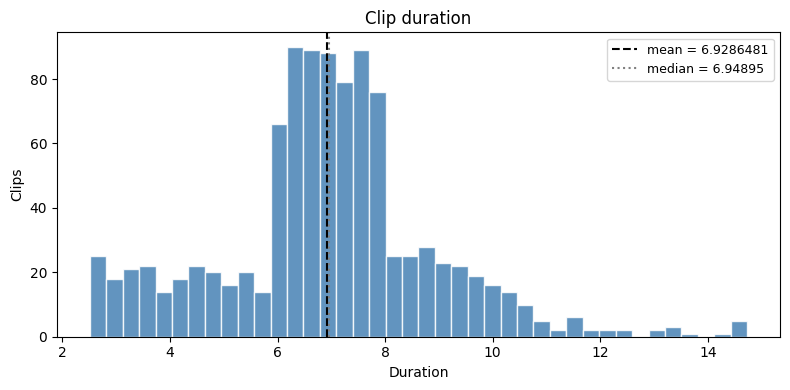

In [36]:
fig, ax = plt.subplots(figsize=(8, 4))
d = m_urgent["duration_sec"]

ax.hist(d, bins=40, color="steelblue", edgecolor="white", alpha=0.85)
ax.axvline(d.mean(), color="black", linestyle="--", label=f"mean = {d.mean()}")
ax.axvline(d.median(), color="grey", linestyle=":",  label=f"median = {d.median()}")
ax.set_title("Clip duration")
ax.set_xlabel("Duration")
ax.set_ylabel("Clips")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(EDA_DIR / "01_duration.png", dpi=150, bbox_inches="tight")
plt.show()


In [54]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 6. EDA — SNR Distribution

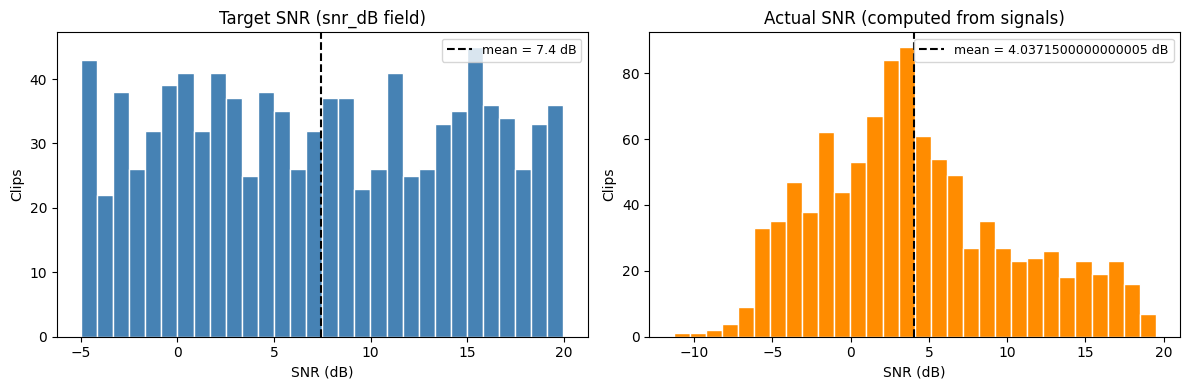

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

snr_t = m_urgent["snr_target_db"].dropna()
axes[0].hist(snr_t, bins=30, color="steelblue", edgecolor="white")
axes[0].axvline(snr_t.mean(), color="black", linestyle="--", label=f"mean = {snr_t.mean()} dB")
axes[0].set_title("Target SNR (snr_dB field)")
axes[0].set_xlabel("SNR (dB)")
axes[0].set_ylabel("Clips")
axes[0].legend(fontsize=9)

snr_a = m_urgent["snr_actual_db"].replace([np.inf, -np.inf], np.nan).dropna()
axes[1].hist(snr_a, bins=30, color="darkorange", edgecolor="white")
axes[1].axvline(snr_a.mean(), color="black", linestyle="--", label=f"mean = {snr_a.mean()} dB")
axes[1].set_title("Actual SNR (computed from signals)")
axes[1].set_xlabel("SNR (dB)")
axes[1].set_ylabel("Clips")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(EDA_DIR / "02_snr_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [38]:
print(f"Actual SNR range : {snr_a.min()} to {snr_a.max():} dB")

Actual SNR range : -11.32 to 19.5 dB



## 8. EDA — Amplitude and Signal Quality

In [40]:
sample_indices = random.sample(range(len(urgent_raw)), len(urgent_raw))

amp_rows = []
for i in tqdm(sample_indices, desc="Amplitude stats"):
    s = urgent_raw[i]
    c_arr = np.array(s["clean_audio"]["array"], dtype=np.float32)
    n_arr = np.array(s["noisy_audio"]["array"], dtype=np.float32)
    amp_rows.append({
        "clean_rms" : float(np.sqrt(np.mean(c_arr ** 2))),
        "noisy_rms" : float(np.sqrt(np.mean(n_arr ** 2))),
        "clean_peak": float(np.max(np.abs(c_arr))),
        "noisy_peak": float(np.max(np.abs(n_arr))),
    })

amp_df = pd.DataFrame(amp_rows)
print(amp_df.describe().round(4))

Amplitude stats:   0%|          | 0/1000 [00:00<?, ?it/s]

       clean_rms  noisy_rms  clean_peak  noisy_peak
count  1000.0000  1000.0000   1000.0000   1000.0000
mean      0.0964     0.1113      0.8263      0.6695
std       0.0271     0.0368      0.1230      0.3172
min       0.0102     0.0155      0.0803      0.0507
25%       0.0770     0.0844      0.7959      0.2981
50%       0.0927     0.1107      0.8900      0.9000
75%       0.1137     0.1347      0.9000      0.9000
max       0.2301     0.2517      0.9000      0.9000


In [41]:
SILENCE_THRESHOLD = 0.001

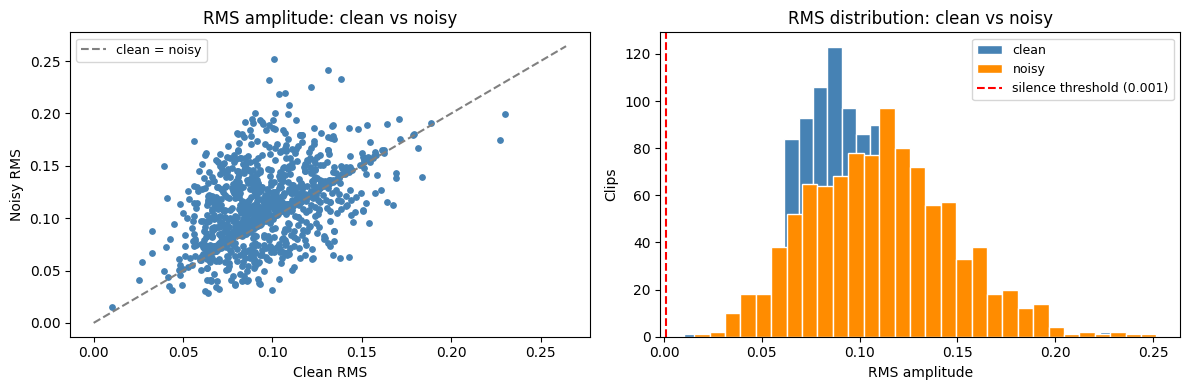

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(amp_df["clean_rms"], amp_df["noisy_rms"], s=15, color="steelblue")
lim = max(amp_df["clean_rms"].max(), amp_df["noisy_rms"].max()) * 1.05
axes[0].plot([0, lim], [0, lim], "--", color="grey", label="clean = noisy")
axes[0].set_title("RMS amplitude: clean vs noisy")
axes[0].set_xlabel("Clean RMS")
axes[0].set_ylabel("Noisy RMS")
axes[0].legend(fontsize=9)

axes[1].hist(amp_df["clean_rms"], bins=30, color="steelblue", edgecolor="white", label="clean")
axes[1].hist(amp_df["noisy_rms"], bins=30, color="darkorange", edgecolor="white", label="noisy")
axes[1].axvline(SILENCE_THRESHOLD, color="red", linestyle="--", label=f"silence threshold ({SILENCE_THRESHOLD})")
axes[1].set_title("RMS distribution: clean vs noisy")
axes[1].set_xlabel("RMS amplitude")
axes[1].set_ylabel("Clips")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(EDA_DIR / "04_amplitude.png", dpi=150, bbox_inches="tight")
plt.show()


## 9. EDA — Spectral Visualization

A spectrogram comparison of one clean/noisy pair gives an intuitive picture of what  
the enhancement models need to remove. We pick one example per SNR level.

In [ ]:
def plot_spectrogram_pair(clean, noisy, sr, title, ax_clean, ax_noisy):
    kwargs = dict(sr=sr, n_fft=512, hop_length=128, n_mels=64)
    S_c = librosa.power_to_db(librosa.feature.melspectrogram(y=clean, **kwargs), ref=np.max)
    S_n = librosa.power_to_db(librosa.feature.melspectrogram(y=noisy, **kwargs), ref=np.max)
    vmin, vmax = min(S_c.min(), S_n.min()), max(S_c.max(), S_n.max())
    librosa.display.specshow(S_c, sr=sr, hop_length=128,
                             x_axis="time", y_axis="mel", ax=ax_clean, vmin=vmin, vmax=vmax)
    ax_clean.set_title(f"Clean — {title}")
    librosa.display.specshow(S_n, sr=sr, hop_length=128,
                             x_axis="time", y_axis="mel", ax=ax_noisy, vmin=vmin, vmax=vmax)
    ax_noisy.set_title(f"Noisy — {title}")

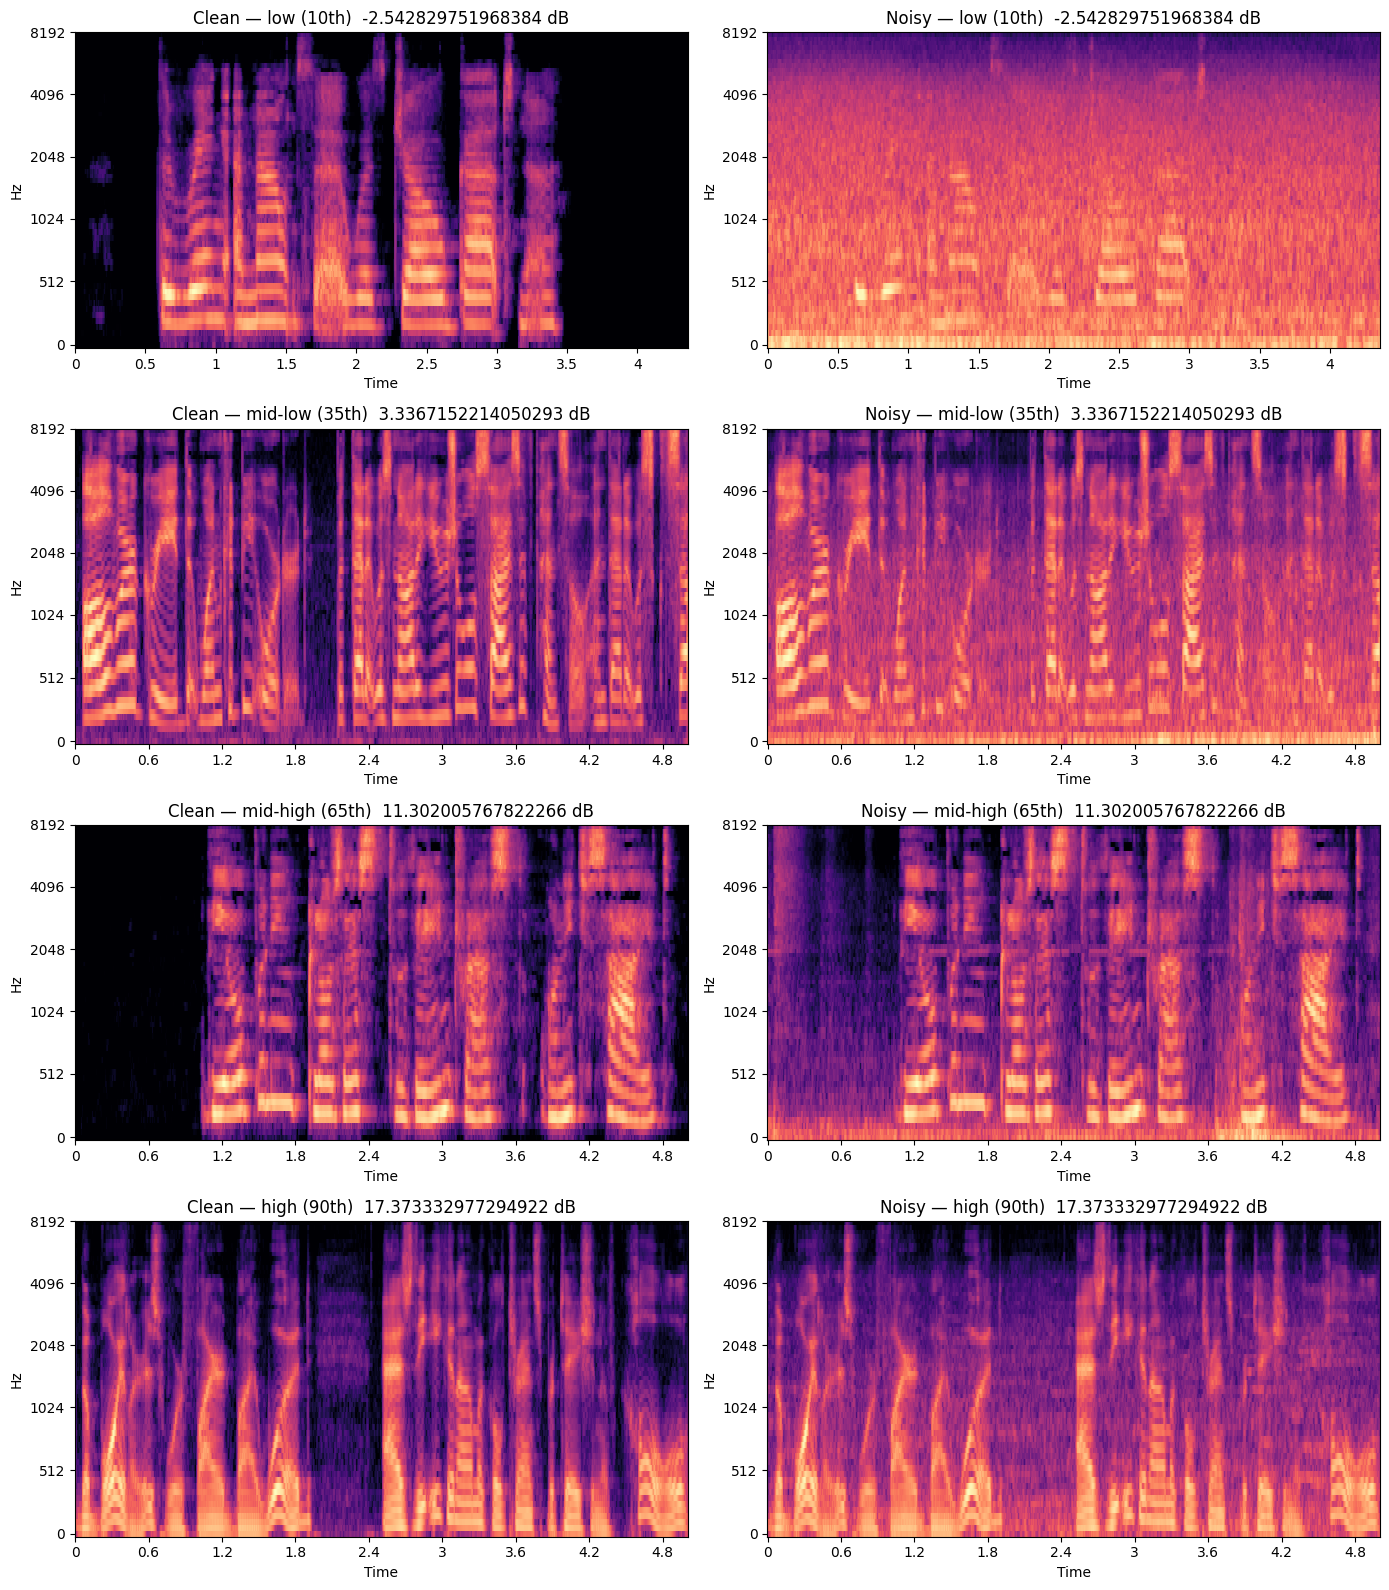

In [45]:
snr_quartiles = m_urgent["snr_target_db"].quantile([0.1, 0.35, 0.65, 0.9])
examples = {}
for q_label, q_val in zip(["low (10th)", "mid-low (35th)", "mid-high (65th)", "high (90th)"],snr_quartiles):
    idx = (m_urgent["snr_target_db"] - q_val).abs().idxmin()
    row = m_urgent.iloc[idx]
    examples[f"{q_label}  {row['snr_target_db']} dB"] = row

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
for row_axes, (label, row) in zip(axes, examples.items()):
    c_arr, _ = librosa.load(row["clean_path"], sr=TARGET_SR)
    n_arr, _ = librosa.load(row["noisy_path"], sr=TARGET_SR)
    plot_spectrogram_pair(c_arr[:TARGET_SR * 5], n_arr[:TARGET_SR * 5], sr=TARGET_SR, title=label,
                          ax_clean=row_axes[0], ax_noisy=row_axes[1])

plt.tight_layout()
plt.savefig(EDA_DIR / "05_spectrograms.png", dpi=150, bbox_inches="tight")
plt.show()


## 10. Dataset Summary Table

In [47]:
summary = {
    "Dataset": "URGENT 2024 non-blind test",
    "Number of Pairs": len(m_urgent),
    "Total hours": round(m_urgent["duration_sec"].sum() / 3600, 2),
    "Duration mean (s)": round(m_urgent["duration_sec"].mean(), 2),
    "Duration min (s)": round(m_urgent["duration_sec"].min(), 2),
    "Duration max (s)": round(m_urgent["duration_sec"].max(), 2),
    "SNR mean (dB)": round(m_urgent["snr_target_db"].mean(), 1),
    "SNR range (dB)": f"{m_urgent['snr_target_db'].min():.1f} – {m_urgent['snr_target_db'].max():.1f}",
    "SR values (orig)": str(sorted(m_urgent["orig_sr"].unique().tolist())),
    "Sample rate": TARGET_SR,
    "Normalized": False,
    "Format": f"mono WAV {TARGET_SUBTYPE}",
}

summary_df = pd.DataFrame([summary]).set_index("Dataset")
print(summary_df.T.to_string())

Dataset                            URGENT 2024 non-blind test
Number of Pairs                                          1000
Total hours                                              1.92
Duration mean (s)                                        6.93
Duration min (s)                                         2.51
Duration max (s)                                        14.73
SNR mean (dB)                                             7.4
SNR range (dB)                                    -5.0 – 20.0
SR values (orig)   [16000, 22050, 24000, 32000, 44100, 48000]
Sample rate                                             16000
Normalized                                              False
Format                                        mono WAV PCM_16
